# Connected Component Analysis - CCA

In [296]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Imports

In [297]:
from skimage.measure import regionprops
import skimage as ski
import imageio.v3 as iio
import numpy as np
import matplotlib.pyplot as plt


In [298]:
filename = "/content/drive/MyDrive/Colab Notebooks/images/shapes-01.jpg"

In [306]:
def connected_components(filename, sigma=1.0, connectivity=2):
  image = iio.imread(filename)

  # convert to HSV
  hsv = ski.color.rgb2hsv(image)

  # take saturation channel
  saturation = hsv[:, :, 1]

  # threshold saturation (objects = True)
  binary_mask = saturation > 0.2


  # gray_image = ski.color.rgb2gray(image)
  # blurred_image = ski.filters.gaussian(gray_image, sigma=sigma)
  # t = ski.filters.threshold_otsu(blurred_image)
  # binary_mask = blurred_image < t
  binary_mask = ski.morphology.remove_small_objects(binary_mask, min_size=2200)

  labeled_image, count = ski.measure.label(
      binary_mask, connectivity=connectivity, return_num=True
    )
  props = regionprops(labeled_image)
  areas = [p.area for p in props]
  return binary_mask, labeled_image, count, areas

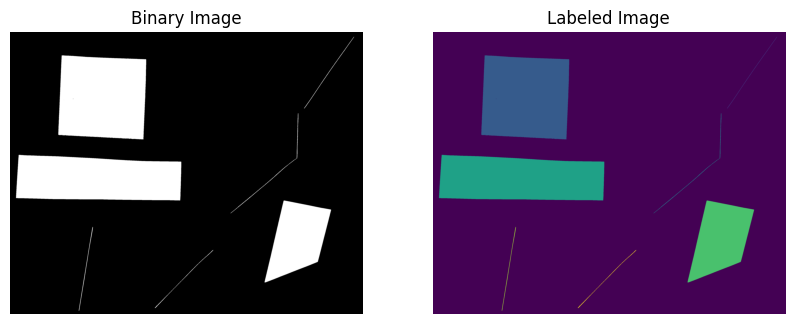


 Number of connected components: 7


In [303]:
binary, labeled, count, areas= connected_components(filename=filename, sigma=1.0, connectivity=2)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(binary, cmap='gray')
ax[0].set_title("Binary Image")
ax[0].axis("off")

ax[1].imshow(labeled)
ax[1].set_title("Labeled Image")
ax[1].axis("off")

plt.show()

print("\n Number of connected components:", count)

Conclusion: Segmentation based on grayscale intensity was insuffiicient because the objects differed primarily in color rather than brightness. Therefore the image was converted to HSV color space and the saturation channel was used, as it effectively separates colored objects from a white background.

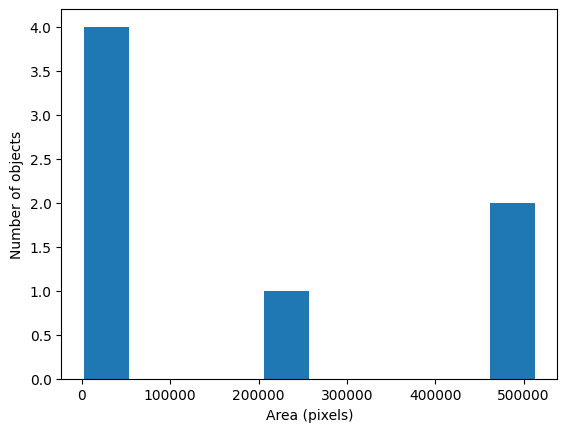

In [304]:
fig, ax = plt.subplots()
ax.hist(areas)
ax.set_xlabel("Area (pixels)")
ax.set_ylabel("Number of objects");
